# Network Science - UDD

## Redes Bipartitas


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 
---

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import networkx as nx

#### Número de personas que contrajeron COVID

Este es un conjunto de datos generado aleatoriamente para ilustrar la construcción de redes bipartitas a partir de conjuntos de datos tabulares empíricos.

En este conjunto de datos, hay variantes de COVID y los nombres enumerados para cada variante son aquellos que fueron infectados con esa variante.

El objetivo de esta práctica es que te familiarices con este tipo de datos estructurados que no están en forma de lista de aristas, sino que se asemejan a fuentes de datos de investigaciones empíricas. A partir de estos datos, deberías ser capaz de crear una red bipartita, así como la lista de nodos y la lista de aristas para cada una de las proyecciones de la red.

In [33]:
data = pd.read_csv('./Data/COVIDvariants.csv')

In [36]:
data.head()

,Variant1,Variant2,Variant3,Variant4,Variant5,Variant6,Variant7,Variant8,Variant9,Variant10
0,Charlie,Frank,Quinn,Oliver,Charlie,Helen,Grace,Rachel,Michael,Grace
1,Sam,David,David,Nina,Nadia,Bob,Ivy,Laura,Tina,Ronald
2,Nina,Oliver,Charlie,Helen,Paul,Eva,Quinn,Sam,Ivy,Bob
3,Alice,Quinn,Bob,Quinn,Sam,Jack,Kevin,Michael,Frank,Nina
4,Kevin,Sam,Rachel,Jack,Kevin,Frank,Eva,Alice,Quinn,Laura


Convert the dataset to the edgelist of a bipartite network, where one level (col1 = 'variant') are the variants and another level (col2 = 'name') are the infected individuals.

In [37]:
df = data.melt(var_name='variant', value_name='name').dropna()

In [38]:
df

,variant,name
0,Variant1,Charlie
1,Variant1,Sam
2,Variant1,Nina
3,Variant1,Alice
4,Variant1,Kevin
...,...,...
395,Variant10,Sarah
396,Variant10,Paula
397,Variant10,Ted
398,Variant10,Arthur


In [39]:
g = nx.Graph()

In [40]:
g = nx.from_pandas_edgelist(df, source='variant', target='name')

In [41]:
# print(nx.info(g))
print(g)

Graph with 69 nodes and 221 edges


In [42]:
g.degree('Ivy')#  degree de un nodo

4

In [43]:
g.degree('Variant1')#  degree de un nodo

41

In [44]:
variants = list(df.variant.unique())#  lista de variantes
variants

['Variant1',
 'Variant2',
 'Variant3',
 'Variant4',
 'Variant5',
 'Variant6',
 'Variant7',
 'Variant8',
 'Variant9',
 'Variant10']

In [45]:
people = list(df.name.unique())#  lista de personas
people

['Charlie',
 'Sam',
 'Nina',
 'Alice',
 'Kevin',
 'Helen',
 'Paul',
 'Grace',
 'Frank',
 'Rachel',
 'Bob',
 'Laura',
 'Bettany',
 'David',
 'Tina',
 'Eva',
 'Jack',
 'Michael',
 'Quinn',
 'Lisa',
 'Chad',
 'Martin',
 'James',
 'Julio',
 'Anna',
 'Alfred',
 'Sofia',
 'Mason',
 'Elizabeth',
 'Andrew',
 'Anthony',
 'Melissa',
 'Newt',
 'Jules',
 'Jackie',
 'Leslie',
 'Marcela',
 'Maggie',
 'Nadia',
 'Lars',
 'Mark',
 'Oliver',
 'Giovanny',
 'Ivy',
 'Sarah',
 'Ronald',
 'Alan',
 'Rose',
 'Rita',
 'Louis',
 'Ted',
 'Arthur',
 'Matilda',
 'Mike',
 'Paula',
 'Dasha',
 'Veronica',
 'Harry',
 'Robert']

In [46]:
layout = nx.spring_layout(g, k=0.05, iterations=50)

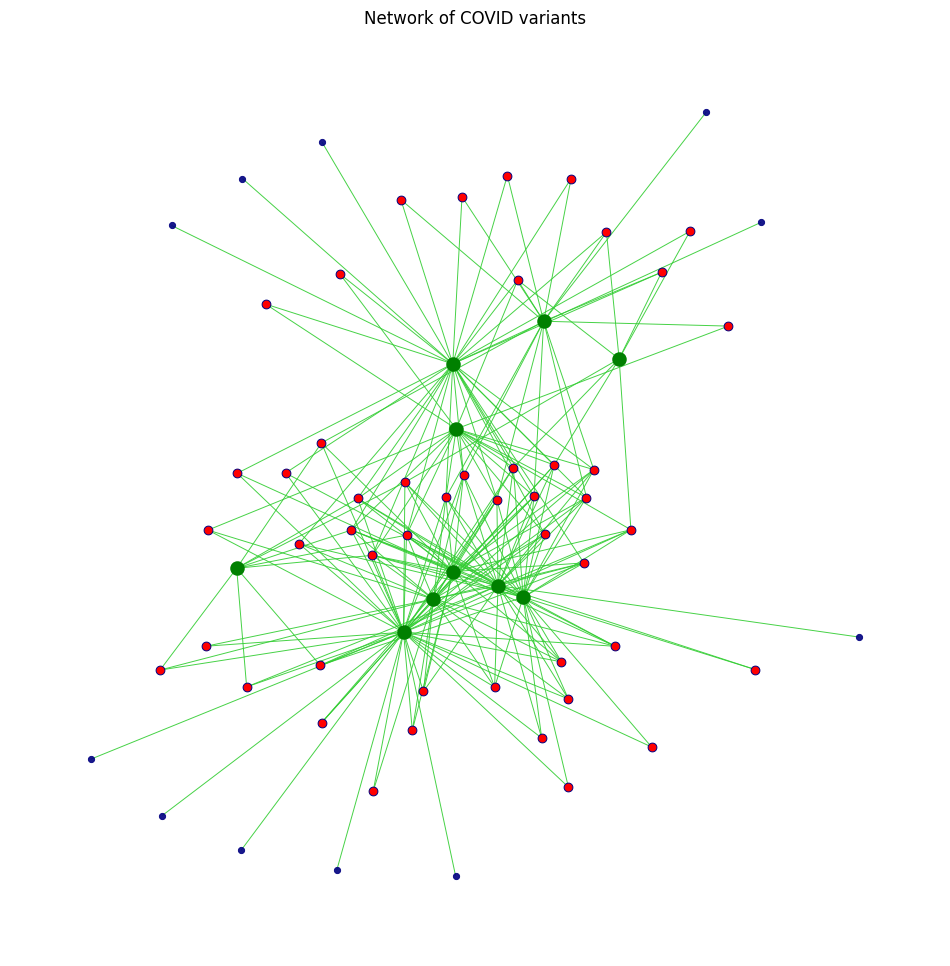

In [47]:
plt.figure(figsize=(12, 12))

# Draw VARIANTS
nx.draw_networkx_nodes(g, 
                       layout, 
                       nodelist=variants, 
                       node_size=80, # a LIST of sizes, based on g.degree
                       node_color='green',
                       edgecolors='green', 
                       linewidths=1.5)


# Draw EVERYONE
nx.draw_networkx_nodes(g, layout, nodelist=people, 
                       node_color='navy', 
                       edgecolors='navy',
                       alpha=0.9,
                       linewidths=0.7, 
                       node_size=20)


# Draw REINFECTED PEOPLE
reinfected_people = [person for person in people if g.degree(person) > 1]
nx.draw_networkx_nodes(g, layout, nodelist=reinfected_people, 
                       node_color='red', 
                       edgecolors='navy',
                       linewidths=0.7,
                       node_size=40)

nx.draw_networkx_edges(g, layout, width=0.7, alpha=0.9,
                       edge_color="limegreen")

# # label people
# node_labels = dict(zip(people, people))
# nx.draw_networkx_labels(g, layout, labels=node_labels,
#                        font_size=8, font_weight='400')


# # label variants
# node_variants = dict(zip(variants, variants))
# nx.draw_networkx_labels(g, layout, labels=node_variants,
#                        font_size=12, font_weight='400')



# Turn off the axis because I know you don't want it
plt.axis('off')

plt.title("Network of COVID variants")
# plt.savefig('network_name.pdf', bbox_inches='tight', pad_inches=0)
# Tell matplotlib to show it
plt.show()

# Tarea

Pregunta 1: ¿Cuál es la naturaleza de la relación entre los dos conjuntos de nodos en la red bipartita?

Pregunta 2: ¿Cuáles son las redes proyectadas de cada conjunto de nodos? (es decir, redes separadas para cada conjunto)

Ejercicio: Construye la matriz de adyacencia de sus dos proyecciones, en los nodos morados y en los nodos verdes, respectivamente. Vea el ejemplo a continuación. Luego, explique la relevancia de cada proyección.

**Project to unipartite: Infected people**

In [48]:
wide_df = df.pivot_table(index='variant', columns=df.groupby('variant').cumcount(), values='name', aggfunc='first')# pivot table para convertir a formato ancho
wide_df

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
variant,,,,,,,,,,,,,,,,,,,,,
Variant1,Charlie,Sam,Nina,Alice,Kevin,Helen,Paul,Grace,Frank,Rachel,...,Melissa,Newt,Jules,Jackie,Leslie,Marcela,Maggie,Nadia,Lars,Mark
Variant10,Grace,Ronald,Bob,Nina,Laura,Alice,Rachel,Ivy,Sam,Michael,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant2,Frank,David,Oliver,Quinn,Sam,Jack,Paul,Charlie,Grace,Helen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant3,Quinn,David,Charlie,Bob,Rachel,Alice,Nadia,Sam,Tina,Jack,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant4,Oliver,Nina,Helen,Quinn,Jack,Charlie,Paul,Laura,David,Alice,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant5,Charlie,Nadia,Paul,Sam,Kevin,Rachel,Frank,David,Alice,Laura,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant6,Helen,Bob,Eva,Jack,Frank,Martin,Julio,Sofia,Maggie,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant7,Grace,Ivy,Quinn,Kevin,Eva,Sarah,Ronald,Alan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant8,Rachel,Laura,Sam,Michael,Alice,Nina,Ivy,Martin,Ronald,Rose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
wide_df.columns = [f'Name{i+1}' for i in range(wide_df.shape[1])]# renombrar columnas
wide_df

,Name1,Name2,Name3,Name4,Name5,Name6,Name7,Name8,Name9,Name10,...,Name32,Name33,Name34,Name35,Name36,Name37,Name38,Name39,Name40,Name41
variant,,,,,,,,,,,,,,,,,,,,,
Variant1,Charlie,Sam,Nina,Alice,Kevin,Helen,Paul,Grace,Frank,Rachel,...,Melissa,Newt,Jules,Jackie,Leslie,Marcela,Maggie,Nadia,Lars,Mark
Variant10,Grace,Ronald,Bob,Nina,Laura,Alice,Rachel,Ivy,Sam,Michael,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant2,Frank,David,Oliver,Quinn,Sam,Jack,Paul,Charlie,Grace,Helen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant3,Quinn,David,Charlie,Bob,Rachel,Alice,Nadia,Sam,Tina,Jack,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant4,Oliver,Nina,Helen,Quinn,Jack,Charlie,Paul,Laura,David,Alice,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant5,Charlie,Nadia,Paul,Sam,Kevin,Rachel,Frank,David,Alice,Laura,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant6,Helen,Bob,Eva,Jack,Frank,Martin,Julio,Sofia,Maggie,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant7,Grace,Ivy,Quinn,Kevin,Eva,Sarah,Ronald,Alan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant8,Rachel,Laura,Sam,Michael,Alice,Nina,Ivy,Martin,Ronald,Rose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Initialize empty lists to store source and target names
source = []
target = []

#   Create edges between all pairs of names in each variant
# Iterate through DataFrame rows
for index, row in wide_df.iterrows():
    # Iterate through column names in the current row
    for i, name1 in enumerate(row): #  Iterar a través de los nombres en la fila actual comenzando desde la siguiente columna
        for j, name2 in enumerate(row[i+1:]): # Iterar a través de los nombres en la fila actual comenzando desde la siguiente columna
            # Append source and target names to the lists
            source.append(name1)
            target.append(name2)

# Create a new DataFrame from the source and target lists
people_df = pd.DataFrame({'Source': source, 'Target': target})

In [52]:
people_df = people_df.dropna()# eliminar filas con valores NaN
people_df

,Source,Target
0,Charlie,Sam
1,Charlie,Nina
2,Charlie,Alice
3,Charlie,Kevin
4,Charlie,Helen
...,...,...
7876,Alice,Helen
7877,Alice,Rita
7900,Sam,Helen
7901,Sam,Rita


In [55]:
new_df = people_df.drop_duplicates()# eliminar filas duplicadas
new_df

,Source,Target
0,Charlie,Sam
1,Charlie,Nina
2,Charlie,Alice
3,Charlie,Kevin
4,Charlie,Helen
...,...,...
7771,Paula,Rita
7799,Grace,Rita
7826,Kevin,Rita
7852,Jack,Rita


In [56]:
new_df = new_df[new_df['Source'] != new_df['Target']]# eliminar filas donde Source y Target son iguales

In [57]:
h = nx.from_pandas_edgelist(new_df, source='Source', target='Target') # crear grafo a partir del DataFrame de personas

In [58]:
layout_h = nx.spring_layout(h, k=0.1, iterations=50)

In [59]:
labels = {node: h.nodes[node].get('label', f'Node {node}') for node in h.nodes}

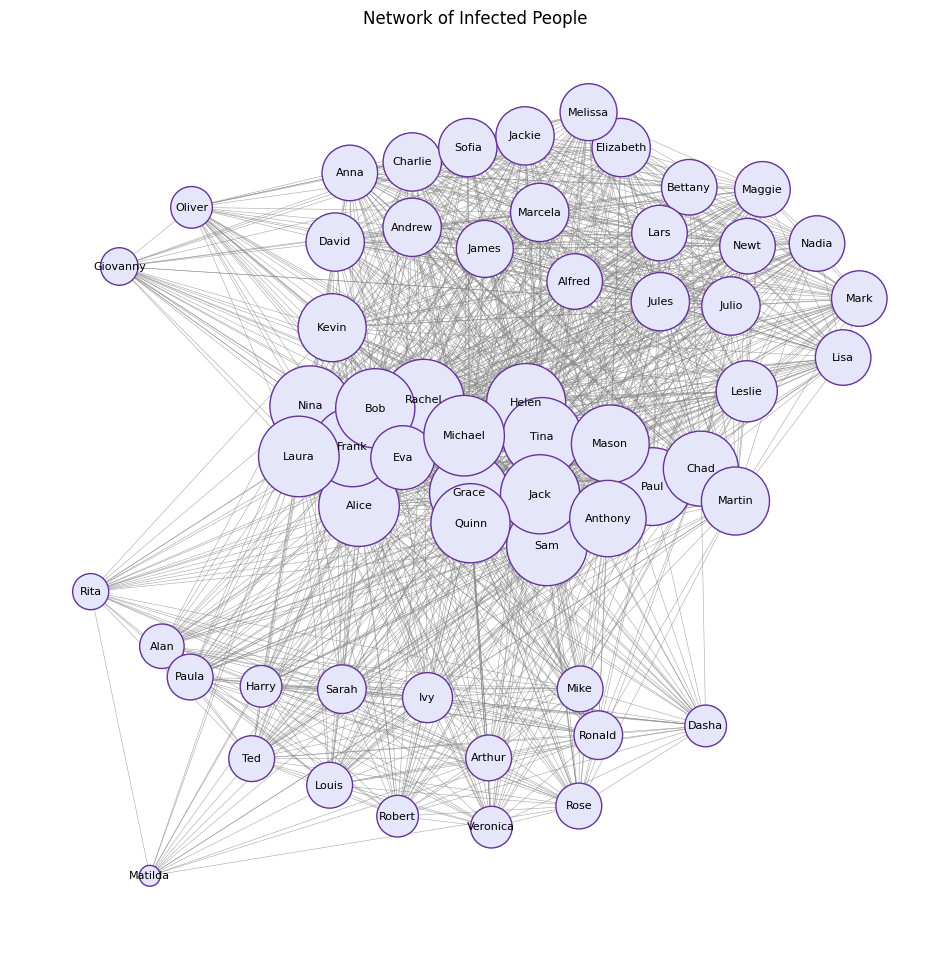

In [60]:
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(h, 
                       layout_h, 
                       node_size=[(h.degree(v)) ** 2 for v in h.nodes()], # sizes based on h.degree
                       node_color='lavender',
                       edgecolors='rebeccapurple',
                       linewidths=1)


nx.draw_networkx_edges(h, layout_h, width=0.4, alpha=0.7, edge_color="gray")


node_labels = dict(zip(labels, labels))
nx.draw_networkx_labels(h, layout_h, labels=node_labels,
                       font_size=8)


plt.axis('off')
plt.title("Network of Infected People")
# plt.savefig('network_projection_name.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

# Tarea

Pregunta 1: ¿Cuáles son las redes proyectadas de cada conjunto de nodos? (es decir, redes separadas para cada conjunto)

Pregunta 2: ¿Qué información puedes obtener de cada proyección?

Pregunta 3: Explica la utilidad de las proyecciones de redes con respecto a la visualización y análisis de la red bipartita.

Ejercicio 1: Calcula el grado promedio de cada proyección de la red, luego calcula el grado promedio de los nodos morados y los nodos verdes en la red bipartita. ¿Cuáles son las diferencias en la distribución? Por favor, explica por qué.
